Imports

In [ ]:
import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import os

C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\io\image.py:14: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Initializations

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10
NUM_FOLDS = 5

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Dataset Prep

In [5]:
train_dataset = datasets.ImageFolder(root="./CIFAKE/train", transform=transform)
test_dataset = datasets.ImageFolder(root="./CIFAKE/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

ResNet Implementation

In [6]:
# Load pre-trained ResNet50
resnet = models.resnet50(pretrained=True)


C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# Freeze all layers (optional, see Step 3 to unfreeze)
for param in resnet.parameters():
    param.requires_grad = False

# Replace the classifier head
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 1),       # Output logits
    nn.Sigmoid()             # Use this only if you're using BCELoss (not BCEWithLogitsLoss)
)

resnet = resnet.to(device)


In [8]:
# Optionally unfreeze later
for param in resnet.layer4.parameters():  # Or resnet.parameters() to unfreeze all
    param.requires_grad = True


In [9]:
criterion = nn.BCELoss()  # Since final output is sigmoid
optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4)

In [ ]:
def train_resnet_cv(train_dataset, test_loader, model_class, device, epochs=10, folds=5, batch_size=64):
    kfold = KFold(n_splits=folds, shuffle=True, random_state=42)
    scores = {"accuracy": [], "precision": [], "recall": [], "f1_score": [], "roc_auc": []}

    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
        print(f"\nFold {fold+1}/{folds}")

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(train_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        # Load a fresh ResNet50
        model = model_class
        criterion = nn.BCELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        # Train the model
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.float().to(device).view(-1, 1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)

            # Validation phase
            model.eval()
            val_loss = 0.0
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.float().to(device).view(-1, 1)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

                    probs = outputs.cpu().numpy().flatten()
                    preds = (probs > 0.5).astype(int)

                    all_probs.extend(probs)
                    all_preds.extend(preds)
                    all_labels.extend(labels.cpu().numpy().flatten())

            acc = accuracy_score(all_labels, all_preds)
            precision = precision_score(all_labels, all_preds)
            recall = recall_score(all_labels, all_preds)
            f1 = f1_score(all_labels, all_preds)
            roc_auc = roc_auc_score(all_labels, all_probs)
            avg_val_loss = val_loss / len(val_loader)

            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
            print(f"→ Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, "
                  f"F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
            
        fold_model_path = f"Models/resnet50_cifake_fold{fold+1}.pth"
        torch.save(model.state_dict(), fold_model_path)
        print(f"✅ Fold {fold+1} model saved to: {fold_model_path}")

        scores["accuracy"].append(acc)
        scores["precision"].append(precision)
        scores["recall"].append(recall)
        scores["f1_score"].append(f1)
        scores["roc_auc"].append(roc_auc)

    # Cross-validation summary
    print("\nCross-validation results:")
    for metric, values in scores.items():
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")


In [ ]:
def train_final_model(train_dataset, test_loader, model_class, device, epochs=10, batch_size=64):
    # === Final Training on All Train Data ===
    print("\nTraining final model on full training dataset...")
    full_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    final_model = model_class.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        final_model.train()
        train_loss = 0.0
        for images, labels in full_loader:
            images, labels = images.to(device), labels.float().to(device).view(-1, 1)
            optimizer.zero_grad()
            outputs = final_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Epoch {epoch+1} | Full Train Loss: {train_loss / len(full_loader):.4f}")
    
    final_model_path = "Models/resnet50_cifake_final_model.pth"
    torch.save(final_model.state_dict(), final_model_path)
    print(f"\n✅ Final full-data model saved to: {final_model_path}")

    # === Final Evaluation on Test Data ===
    final_model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.float().to(device).view(-1, 1)
            outputs = final_model(images)
            probs = outputs.cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_probs)

    print(f"\n📊 Final Test Results:")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

    return final_model


In [12]:
trained_model = train_resnet_cv(train_dataset, test_loader, model_class=resnet, device=device, epochs=5)


Fold 1/5
Epoch 1: Train Loss = 0.2520, Val Loss = 0.1724
→ Accuracy: 0.9317, Precision: 0.9229, Recall: 0.9416, F1: 0.9321, ROC-AUC: 0.9821
Epoch 2: Train Loss = 0.1405, Val Loss = 0.1543
→ Accuracy: 0.9391, Precision: 0.9440, Recall: 0.9331, F1: 0.9385, ROC-AUC: 0.9855
Epoch 3: Train Loss = 0.0967, Val Loss = 0.1539
→ Accuracy: 0.9418, Precision: 0.9299, Recall: 0.9551, F1: 0.9424, ROC-AUC: 0.9866
Epoch 4: Train Loss = 0.0713, Val Loss = 0.1762
→ Accuracy: 0.9406, Precision: 0.9410, Recall: 0.9398, F1: 0.9404, ROC-AUC: 0.9853
Epoch 5: Train Loss = 0.0562, Val Loss = 0.1771
→ Accuracy: 0.9412, Precision: 0.9414, Recall: 0.9405, F1: 0.9410, ROC-AUC: 0.9858
✅ Fold 1 model saved to: resnet50_cifake_fold1.pth

Fold 2/5
Epoch 1: Train Loss = 0.0852, Val Loss = 0.0339
→ Accuracy: 0.9918, Precision: 0.9892, Recall: 0.9943, F1: 0.9918, ROC-AUC: 0.9997
Epoch 2: Train Loss = 0.0554, Val Loss = 0.0342
→ Accuracy: 0.9883, Precision: 0.9912, Recall: 0.9854, F1: 0.9883, ROC-AUC: 0.9994
Epoch 3: Tra

In [13]:
trained_model = train_final_model(train_dataset, test_loader, model_class=resnet, device=device, epochs=5)


Training final model on full training dataset...
Epoch 1 | Full Train Loss: 0.0191
Epoch 2 | Full Train Loss: 0.0150
Epoch 3 | Full Train Loss: 0.0150
Epoch 4 | Full Train Loss: 0.0152
Epoch 5 | Full Train Loss: 0.0147

✅ Final full-data model saved to: resnet50_cifake_final_model.pth

📊 Final Test Results:
Accuracy: 0.9510, Precision: 0.9457, Recall: 0.9571, F1: 0.9513, ROC-AUC: 0.9894


In [14]:
def ResNetModel():
    model = models.resnet50(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )
    return model

Confusion matrix

In [16]:
def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).cpu().numpy()
            preds = (outputs > 0.5).astype(int)  # Convert sigmoid output to binary
            
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call function to plot confusion matrix
# plot_confusion_matrix(final_model, test_loader)

ROC curve

In [17]:
def plot_roc_curve(model, test_loader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).cpu().numpy()
            
            all_probs.extend(outputs.flatten())  # Get probabilities
            all_labels.extend(labels.cpu().numpy().flatten())

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

# Call function to plot ROC curve
# plot_roc_curve(final_model, test_loader)

Checking saved models on test set

C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\sapat\AppData\Local\Temp\ipykernel_36100\450253089.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github


📊 Final Test Results:
Accuracy: 0.9520, Precision: 0.9581, Recall: 0.9454, F1: 0.9517, ROC-AUC: 0.9889


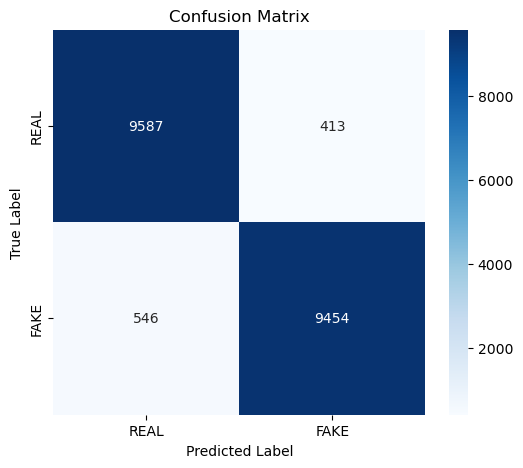

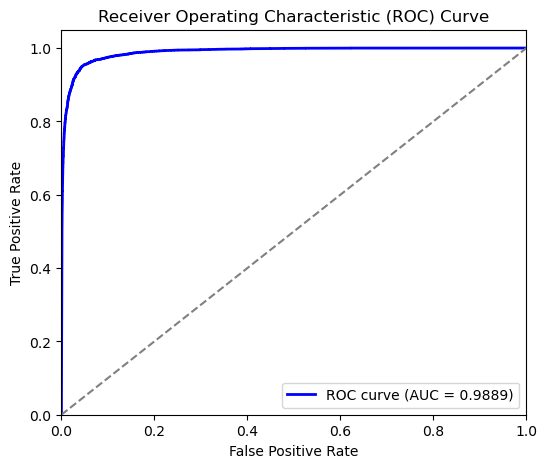

In [18]:
final_model = ResNetModel().to(device)
final_model.load_state_dict(torch.load('resnet50_cifake_fold4.pth'))

final_model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().to(device).view(-1, 1)
        outputs = final_model(images)
        probs = outputs.cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy().flatten())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"\n📊 Final Test Results:")
print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
plot_confusion_matrix(final_model, test_loader)
plot_roc_curve(final_model, test_loader)

Grad-CAM

In [19]:
model = ResNetModel().to(device)
model.load_state_dict(torch.load("resnet50_cifake_fold4.pth"))
model.eval()

# Define same transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ResNet input size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and preprocess an image
real_images = os.listdir("./CIFAKE/test/REAL")
ai_images = os.listdir("./CIFAKE/test/FAKE")
ind = 1333
img_path = f"./CIFAKE/test/FAKE/{real_images[ind][1:]}" 
pil_img = Image.open(img_path).convert("RGB")
input_tensor = transform(pil_img).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sapat\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\sapat\AppData\Local\Temp\ipykernel_36100\3187244948.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://githu

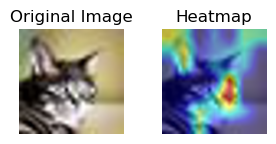

In [20]:
target_layers = [model.layer4[-1]]  # Works for ResNet50

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layers)

# Forward pass target (1 = FAKE, 0 = REAL)
target_class = BinaryClassifierOutputTarget(1)

# Generate Grad-CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=[target_class])[0]  # (H, W)

# Convert image to numpy [0,1] range
rgb_img = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0

# Overlay heatmap
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(3, 1.5))

axes[0].imshow(rgb_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title("Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
model = ResNetModel().to(device)
model.load_state_dict(torch.load("resnet50_cifake_fold4.pth"))
model.eval()

# Define same transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ResNet input size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and preprocess an image
real_images = os.listdir("./CIFAKE/test/REAL")
ai_images = os.listdir("./CIFAKE/test/FAKE")
ind = 1333
img_path = f"./CIFAKE/test/REAL/{real_images[ind]}" 
pil_img = Image.open(img_path).convert("RGB")
input_tensor = transform(pil_img).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

C:\Users\sapat\AppData\Local\Temp\ipykernel_36100\3058025899.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet50_cifake_fold4.pth"

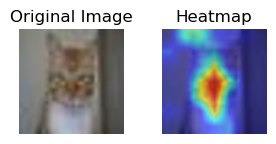

In [22]:
target_layers = [model.layer4[-1]]  # Works for ResNet50

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layers)

# Forward pass target (1 = FAKE, 0 = REAL)
target_class = BinaryClassifierOutputTarget(1)

# Generate Grad-CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=[target_class])[0]  # (H, W)

# Convert image to numpy [0,1] range
rgb_img = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0

# Overlay heatmap
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(3, 1.5))

axes[0].imshow(rgb_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title("Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Misclassified images

In [ ]:
model = ResNetModel().to(device)
model.load_state_dict(torch.load("resnet50_cifake_fold4.pth"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = "misclassified_gradcam"
os.makedirs(output_dir, exist_ok=True)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
# === Grad-CAM setup ===
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# === Loop through test images ===
for i, (image_tensor, label) in enumerate(test_loader):
    image_tensor = image_tensor.to(device)
    label = label.item()

    with torch.no_grad():
        output = model(image_tensor)
        prob = output.item()
        pred = 1 if prob > 0.5 else 0

    # Only keep misclassified images
    if pred != label:
        grayscale_cam = cam(input_tensor=image_tensor, targets=[BinaryClassifierOutputTarget(pred)])[0]

        # Prepare visualization
        unnorm = transforms.Normalize(
            mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
            std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
        )
        image_np = unnorm(image_tensor.squeeze(0)).cpu().numpy().transpose(1, 2, 0)
        image_np = np.clip(image_np, 0, 1)
        cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

        # === Save side-by-side ===
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow(image_np)
        axs[0].set_title("Original")
        axs[0].axis("off")
        axs[1].imshow(cam_image)
        axs[1].set_title(f"Heatmap (Pred: {pred}, True: {label})")
        axs[1].axis("off")

        fname = f"img_{i}_pred{pred}_true{label}.png"
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, fname))
        plt.close()

C:\Users\sapat\AppData\Local\Temp\ipykernel_47260\454187198.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet50_cifake_fold4.pth")

Prediction (Please load one of the models to loaded_model variable before executing the below code)

In [19]:
def predict(image):
    loaded_model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        output = loaded_model(image)
        prediction = "FAKE" if output.item() > 0.5 else "REAL"
    return prediction